In [1]:
# loading datasets
import pandas as pd
import numpy as np

df = pd.read_csv("../../datasets/housing.csv")

features_names = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]

X = df[features_names]
y = df["median_house_value"]

X["total_bedrooms"] = X["total_bedrooms"].fillna(
    X["total_bedrooms"].mean()
)


In [2]:
print(X.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64


In [3]:
print(np.isnan(X).any())
print(np.isnan(y).any())

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms        False
population            False
households            False
median_income         False
dtype: bool
False


In [4]:
# Standardize each feature
X = (X - X.mean()) / X.std()

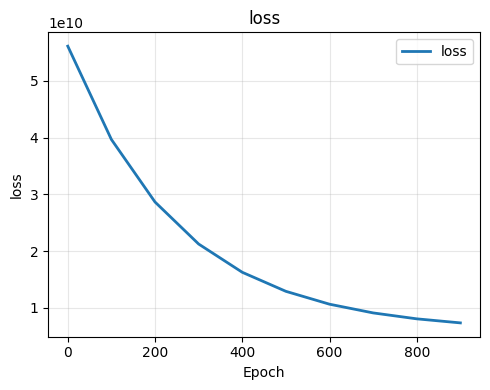

In [12]:
# Training using TrueML LinReg
from trueml.linear_model import LinearRegression
from trueml.losses import MSEloss
import trueml.plots as plt
model = LinearRegression(n_features = X.shape[1], lr=0.001, history=True)
loss_fn = MSEloss()

for epoch in range(1000):
    y_pred = model.forward(X)

    t_loss = loss_fn(y, y_pred)
    d_loss = loss_fn.grad(y, y_pred)

    dw, db = model.grad(X, d_loss)

    model.backward(dw, db)

    if epoch % 100 == 0:
        model.history.append(epoch, loss=t_loss)
